# Heart Disease Model Training Notebook

# Project Objective

Heart Disease Prediction using Machine Learning is crucial because early detection significantly improves treatment outcomes and survival rates. Data-driven prediction systems assist medical professionals in identifying potential cardiovascular risks at an early stage.

In this project, a heart disease dataset was analyzed and processed using appropriate preprocessing techniques. Multiple machine learning classification algorithms were implemented in Python using Scikit-learn and Keras to predict the likelihood of heart disease.

### Algorithms Used:

- Logistic Regression
- Naive Bayes
- Support Vector Machine (Linear)
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- XGBoost
- Artificial Neural Network (1 Hidden Layer, Keras)

## Import Libraries

In [2]:
# Standard libraries
import os
import warnings

# Data libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

## Loading Dataset

In [3]:
df = pd.read_csv("heart.csv")

## Understanding Data Using EDA

In [4]:
# Data head
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# data tail
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
# data Shape
df.shape

(303, 14)

In [7]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Column Description

- **age:** `age`
- **sex:** `1 = male, 0 = female`
- **cp:** `chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic`
- **trestbps:** `resting blood pressure`
- **chol:** `serum cholesterol in mg/dl`
- **fbs:** `fasting blood sugar > 120 mg/dl`
- **restecg:** `resting electrocardiographic results (values 0,1,2)`
- **thalach:** `maximum heart rate achieved`
- **exang:** `exercise induced angina`
- **oldpeak:** `ST depression induced by exercise relative to rest`
- **slope:** `slope of peak exercise ST segment`
- **ca:** `number of major vessels (0–3)`
- **thal:** `3 = normal; 6 = fixed defect; 7 = reversible defect`

In [8]:
# Checking Null values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
# Column Stats
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [10]:
df[df['target']==0].iloc[0]

age          67.0
sex           1.0
cp            0.0
trestbps    160.0
chol        286.0
fbs           0.0
restecg       0.0
thalach     108.0
exang         1.0
oldpeak       1.5
slope         1.0
ca            3.0
thal          2.0
target        0.0
Name: 165, dtype: float64

In [11]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


In [28]:
# Dataset Inspection
for col in df.columns:
    print(f"{col}")
    print("Unique values:", sorted([int(x) for x in df[col].unique()]))
    print("Count:", df[col].nunique())
    print("-"*40)

age
Unique values: [29, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 74, 76, 77]
Count: 41
----------------------------------------
sex
Unique values: [0, 1]
Count: 2
----------------------------------------
cp
Unique values: [0, 1, 2, 3]
Count: 4
----------------------------------------
trestbps
Unique values: [94, 100, 101, 102, 104, 105, 106, 108, 110, 112, 114, 115, 117, 118, 120, 122, 123, 124, 125, 126, 128, 129, 130, 132, 134, 135, 136, 138, 140, 142, 144, 145, 146, 148, 150, 152, 154, 155, 156, 160, 164, 165, 170, 172, 174, 178, 180, 192, 200]
Count: 49
----------------------------------------
chol
Unique values: [126, 131, 141, 149, 157, 160, 164, 166, 167, 168, 169, 172, 174, 175, 176, 177, 178, 180, 182, 183, 184, 185, 186, 187, 188, 192, 193, 195, 196, 197, 198, 199, 200, 201, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

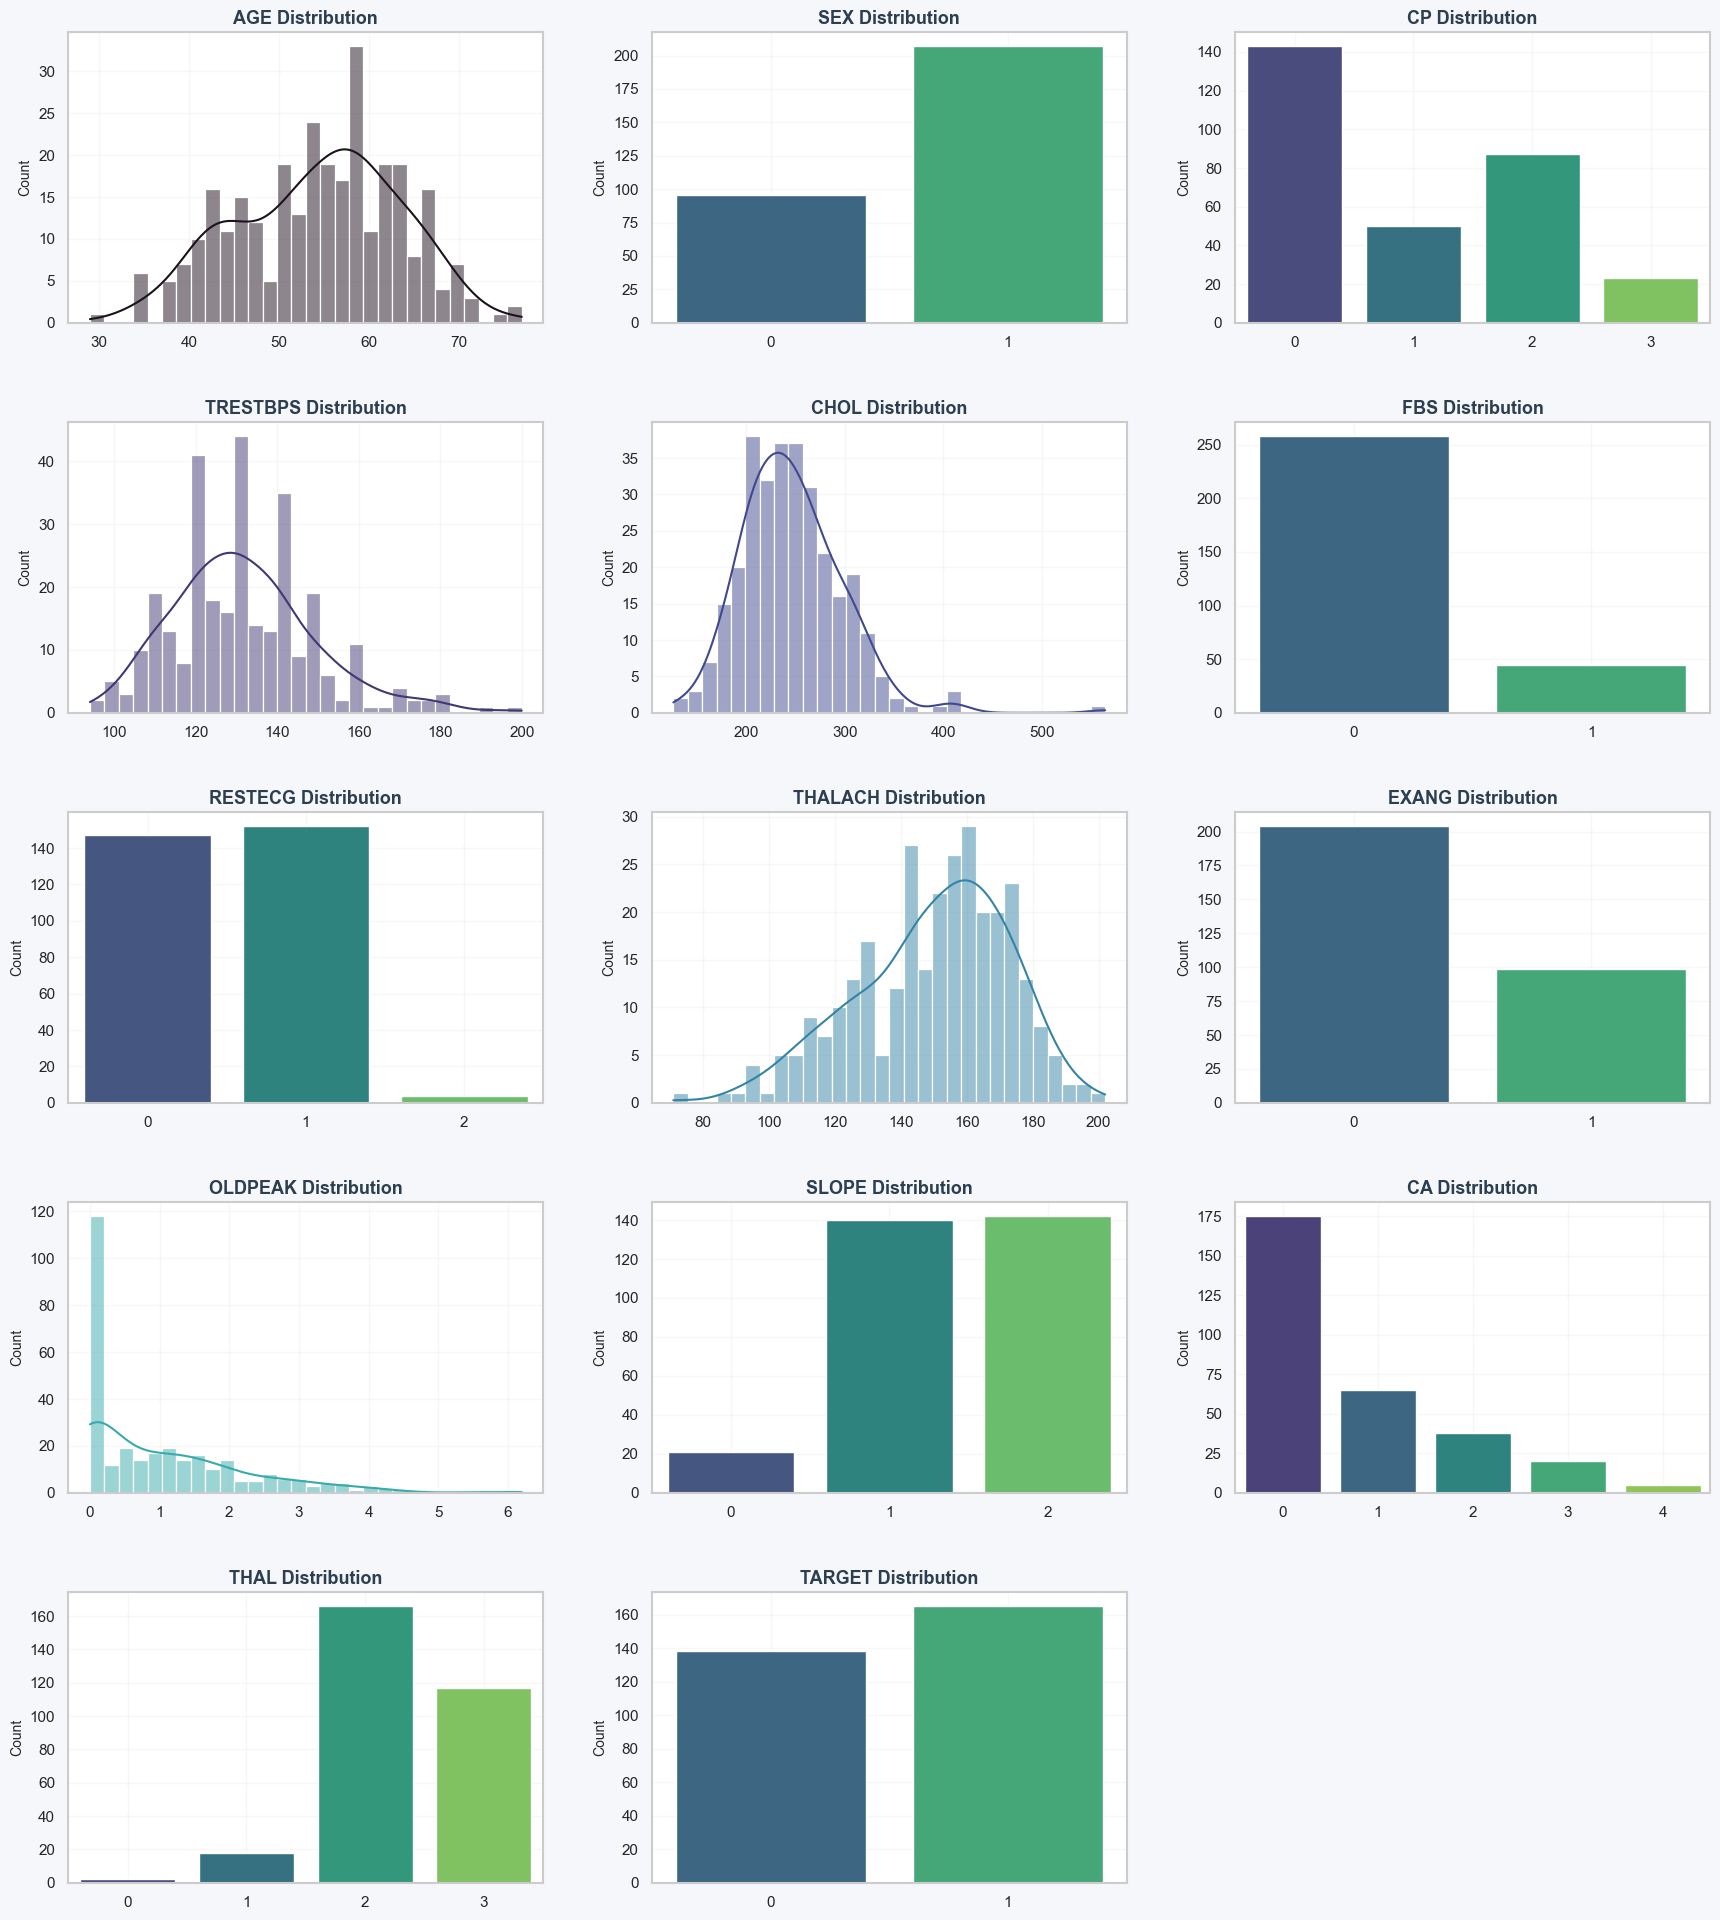

In [30]:
# Each Numerical Feature Hist Plot Distribution

# Modern professional theme
sns.set_theme(style="white")

# Color palette (professional gradient palette)
palette = sns.color_palette("mako", len(df.columns))

# Grid calculation
cols = 3
rows = int(np.ceil(len(df.columns) / cols))

# Figure
fig = plt.figure(figsize=(18, rows * 4))
fig.patch.set_facecolor("#f5f7fa")  # subtle background

for i, col in enumerate(df.columns):
    ax = plt.subplot(rows, cols, i + 1)

    # Box background
    ax.set_facecolor("#ffffff")

    # Border around each plot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#cccccc")
        spine.set_linewidth(1.5)

    # Plot type selection
    if df[col].nunique() < 10:
        sns.countplot(x=df[col], palette="viridis", ax=ax)
    else:
        sns.histplot(df[col], kde=True, color=palette[i], bins=30, ax=ax)

    # Title styling
    ax.set_title(
        f"{col.upper()} Distribution",
        fontsize=13,
        fontweight="bold",
        color="#2c3e50"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=10)

    # Light grid
    ax.grid(alpha=0.15)

# Layout spacing
plt.tight_layout(pad=3)

# Save image (HD quality)
plt.savefig("Professional_Feature_Distribution.png", dpi=300, bbox_inches="tight")

plt.show()

<Axes: xlabel='target', ylabel='count'>

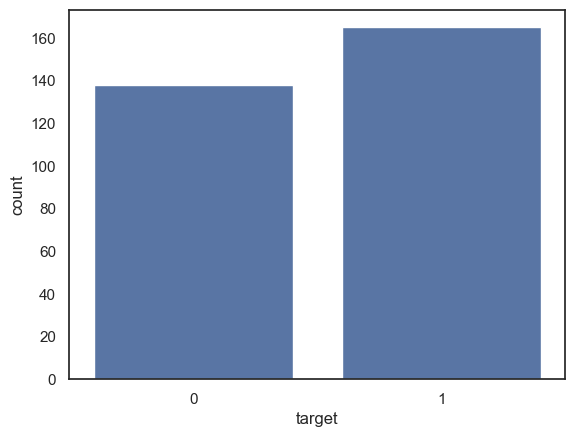

In [31]:
# Checking target class distribution
sns.countplot(x=df["target"])

In [32]:
# Target col not that much imbalance, we can proceed, no need of sampling.

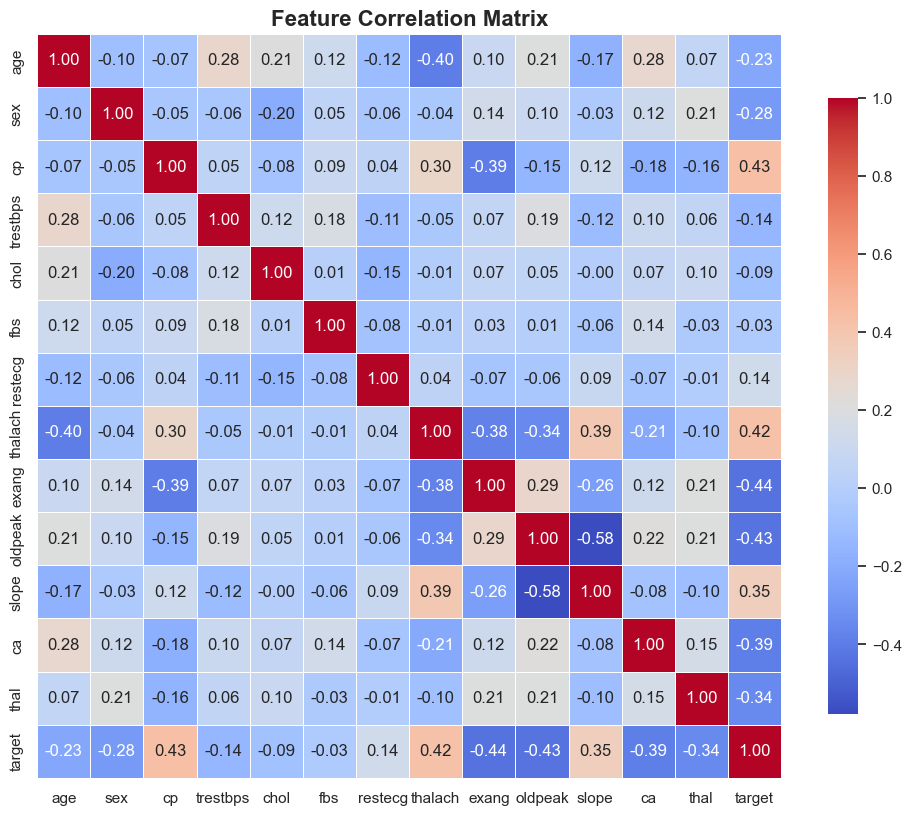

In [33]:
#To check Correlation of Features vs Target
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.show()

In [34]:
# Ranking features based on correlation with target variable
df.corr()['target'].sort_values(ascending = False).reset_index()

,index,target
0,target,1.000000
1,cp,0.433798
2,thalach,0.421741
3,slope,0.345877
4,restecg,0.137230
5,fbs,-0.028046
6,chol,-0.085239
7,trestbps,-0.144931
8,age,-0.225439
9,sex,-0.280937


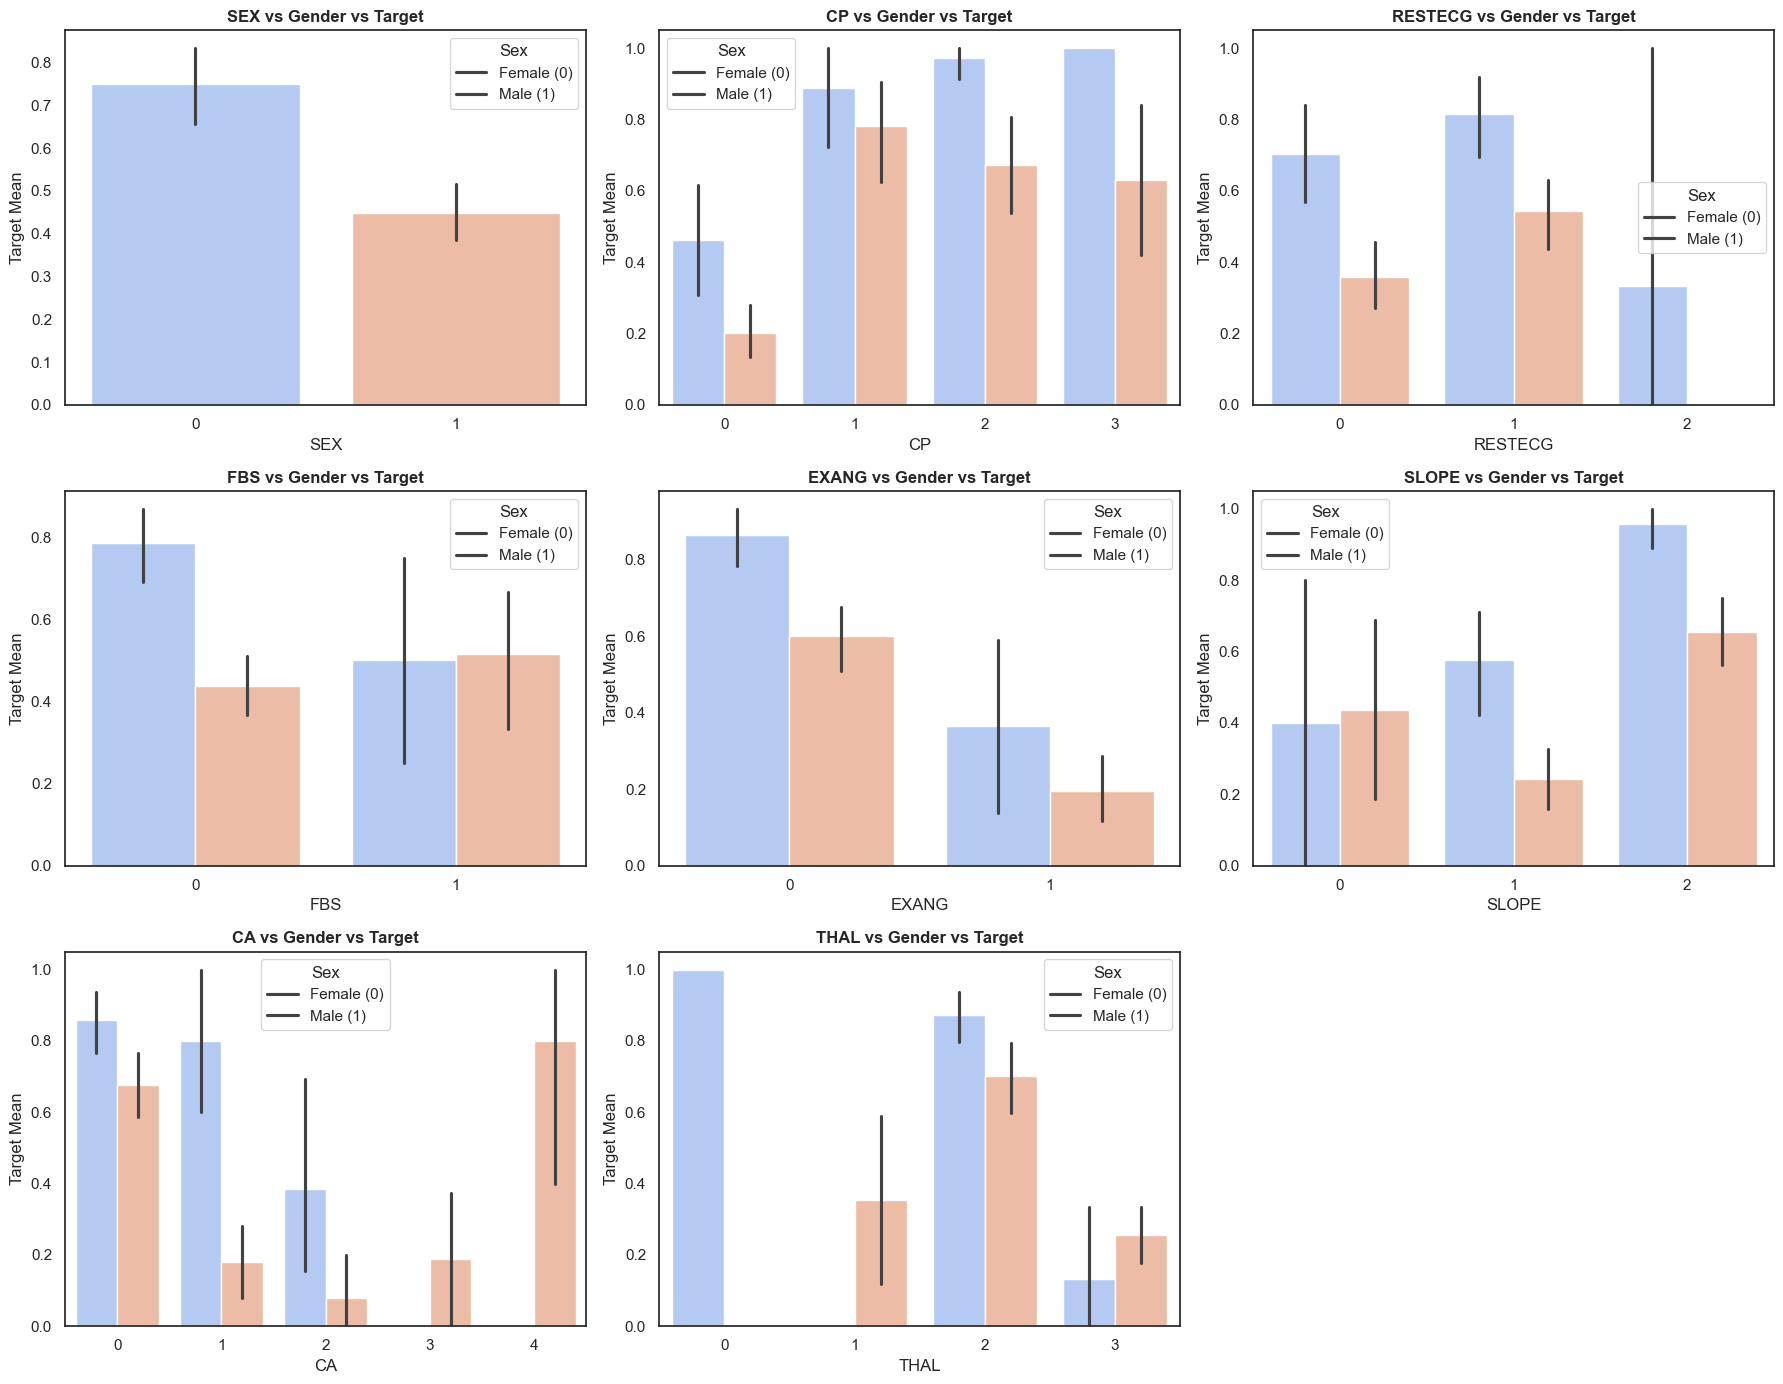

Observation: Certain categorical features show distinct gender-based risk patterns.


In [35]:
# Visualizing relationship between categorical features, gender, and target variable
# to analyze how each feature influences heart disease risk across male and female patients
r = 3
c = 3

features = ['sex','cp','restecg','fbs','exang','slope','ca','thal']

plt.figure(figsize=(18,14))

for i, col in enumerate(features):

    plt.subplot(r, c, i+1)

    sns.barplot(
        data=df,
        x=col,
        y="target",
        hue="sex",
        palette="coolwarm"
    )

    plt.title(f"{col.upper()} vs Gender vs Target", fontsize=12, weight="bold")
    plt.xlabel(col.upper())
    plt.ylabel("Target Mean")

    plt.legend(title="Sex", labels=["Female (0)", "Male (1)"])

plt.tight_layout()
plt.show()
print("Observation: Certain categorical features show distinct gender-based risk patterns.")

## 📊 Exploratory Data Analysis — Conclusion

The exploratory analysis reveals that several clinical features show strong predictive relationships with heart disease. In particular, **chest pain type (cp)**, **ST slope**, **number of major vessels (ca)**, **thalassemia status (thal)**, and **exercise-induced angina (exang)** demonstrate clear variations in disease probability across their categories. The noticeable differences in target averages indicate that these features contain significant diagnostic information and are likely to contribute meaningfully to model performance.

On the other hand, features such as **fasting blood sugar (fbs)** and **resting ECG (restecg)** exhibit relatively small variations across categories, suggesting weaker predictive influence. These variables may provide limited discriminatory power compared to stronger predictors.

Gender-based comparisons show only modest differences in disease probability between male and female groups. While gender may have some influence, it does not appear to be a dominant determinant within this dataset.

Overall, the analysis suggests that heart disease prediction in this dataset is primarily influenced by physiological and clinical indicators rather than demographic attributes. These insights guide feature selection and help prioritize the most informative variables for training machine learning models.

# Dividing Data into Train and Test

In [36]:
# Separating input features (X) and target variable (y) for model training
X = df.drop("target", axis=1)
y = df["target"]

In [37]:
X.shape, y.shape

((303, 13), (303,))

In [38]:
# 4.2 Train - test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


# Multi Model Creation

##### Target variable contains two classes (0 and 1), indicating a binary classification problem.
##### Therefore, classification algorithms will be used instead of regression models.

## Logistic Regression Model

In [42]:
# ============================================================
# Logistic Regression Concept Explanation
# ============================================================
# Logistic Regression is used for Binary Classification problems,
# where the target variable has only two possible outcomes (0 or 1).

# Step 1 — Linear Model
# First, the model calculates a linear combination of inputs:
# z = w1*x1 + w2*x2 + ... + b
# This is similar to a linear regression equation (y = mx + c).
# However, this value can range from -∞ to +∞, which is not suitable
# for probability prediction.

# Step 2 — Sigmoid Transformation
# To convert this linear output into a probability, Logistic Regression
# applies the Sigmoid Function:

#            1
# φ(z) = -----------
#        1 + e^(-z)

# The sigmoid function maps any real number into a value between 0 and 1.
# This output represents probability:
#   close to 0 → class 0 (No disease)
#   close to 1 → class 1 (Disease)

# Step 3 — Decision Boundary
# A threshold (usually 0.5) is applied:
#   if probability >= 0.5 → Predict Class 1
#   else → Predict Class 0

# Summary:
# Logistic Regression = Linear Model + Sigmoid Function + Threshold Decision
# ============================================================

In [43]:
#Import Logistic Regression
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()  # Model object 
model_lr.fit(X_train,y_train)  # Training/Model Building: # Learn Pattern in this step

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [78]:
# Generate predictions on unseen test data to evaluate model generalization
y_pred_lr = model_lr.predict(X_test)


In [79]:
# Import classification evaluation metrics
# These metrics are used to assess performance of classification models
# (Accuracy, Precision, Recall, F1-score, and detailed classification report)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [80]:
# Import Confusion Matrix for classification evaluation
# Used to visualize model performance by comparing actual vs predicted classes
from sklearn.metrics import confusion_matrix

In [81]:
# Note on classification errors and tie situations
# If model scores are tied, additional metrics beyond accuracy should be checked.
# Type I Error (False Positive): Model predicts disease when patient is actually healthy — dangerous because it may cause unnecessary stress or treatment.
# Type II Error (False Negative): Model predicts healthy when patient actually has disease — more critical in medical contexts because real illness is missed.

In [102]:
# Confusion Matrix: compares actual vs predicted labels
# Layout → rows: actual classes | columns: predicted classes
# Useful for evaluating classification performance (TP, TN, FP, FN)
cm_lr = confusion_matrix(y_test, y_pred_lr)

In [103]:
print(cm_lr)

[[25  4]
 [ 3 29]]


In [104]:
# TN(Healthy predicted as Healthy)=25;
#FP(Healthy predicted as Disease)=4; 
#FN(Disease predicted as Healthy)=3; 
#TP(Disease predicted as Disease)=29

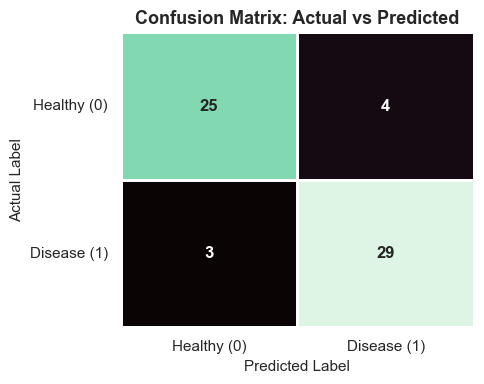

In [105]:
# Visualize Confusion Matrix as a heatmap for clear interpretation
# Rows represent Actual classes and Columns represent Predicted classes
# Helps quickly identify model strengths and types of errors (FP, FN)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12, "weight":"bold"}
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0.5,1.5], ["Healthy (0)", "Disease (1)"])
plt.yticks([0.5,1.5], ["Healthy (0)", "Disease (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [86]:
TN,FP,FN,TP = cm.ravel()

In [87]:
# Manual metric calculations

accuracy_manual = (TN + TP) / cm.sum()
precision_manual = TP / (TP + FP)
recall_manual = TP / (TP + FN)
f1_manual = (2 * TP) / (2 * TP + FP + FN)

accuracy_manual, precision_manual, recall_manual, f1_manual

(np.float64(0.8852459016393442),
 np.float64(0.8787878787878788),
 np.float64(0.90625),
 np.float64(0.8923076923076924))

In [93]:
# Built-in sklearn metrics (validation check)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

accuracy_lr, precision_lr, recall_lr, f1_lr

(0.8852459016393442, 0.8787878787878788, 0.90625, 0.8923076923076924)

In [94]:
# Generate detailed classification evaluation report
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [110]:
# Checking Model Score
# Model Score same as accuracy Score
lr_score = model_lr.score(X_test,y_test)
lr_score

0.8852459016393442

# Naive Bayes ML Model

In [96]:
# pre-assumption: It will pre-assume No correlation b/w features 

In [97]:
# 5.2 Naive Bayes Model Training
# GaussianNB is suitable for continuous numerical features (like this dataset)

from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()          # Initialize model object
model_nb.fit(X_train, y_train)   # Train model on training data

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [100]:
# Generate predictions on unseen test data to evaluate model generalization
y_pred_nb = model_nb.predict(X_test)

In [106]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

[[26  3]
 [ 5 27]]


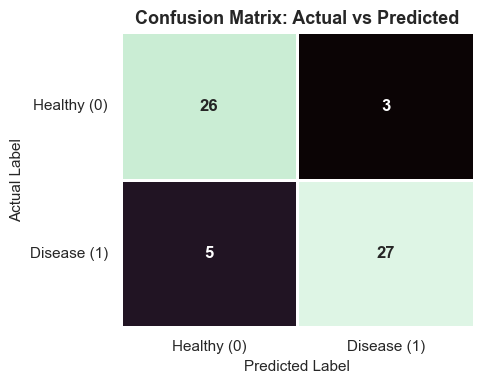

In [107]:
# Visualize Confusion Matrix as a heatmap for clear interpretation
# Rows represent Actual classes and Columns represent Predicted classes
# Helps quickly identify model strengths and types of errors (FP, FN)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12, "weight":"bold"}
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0.5,1.5], ["Healthy (0)", "Disease (1)"])
plt.yticks([0.5,1.5], ["Healthy (0)", "Disease (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [108]:
# Built-in sklearn metrics (validation check)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

accuracy_nb, precision_nb, recall_nb, f1_nb

(0.8688524590163934, 0.9, 0.84375, 0.8709677419354839)

In [109]:
# Generate detailed classification evaluation report
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [111]:
# Checking Model Score
# Model Score same as accuracy Score
nb_score = model_nb.score(X_test,y_test)
nb_score

0.8688524590163934

# Support Vector Machine ML Model

In [112]:
# SVM Works on Support vectos of nearest data points of different classes
# It will create line, plane or Hyperplane
# we can use this for both regression problems and classification(Binary/Multiclass)

In [114]:
from sklearn.svm import SVC
model_svm = SVC()
model_svm.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [115]:
y_pred_svm= model_svm.predict(X_test)

In [116]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

[[15 14]
 [ 4 28]]


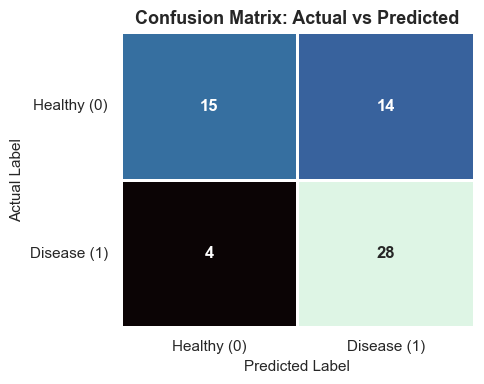

In [117]:
# Visualize Confusion Matrix as a heatmap for clear interpretation
# Rows represent Actual classes and Columns represent Predicted classes
# Helps quickly identify model strengths and types of errors (FP, FN)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12, "weight":"bold"}
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0.5,1.5], ["Healthy (0)", "Disease (1)"])
plt.yticks([0.5,1.5], ["Healthy (0)", "Disease (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [118]:
# Built-in sklearn metrics (validation check)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

accuracy_svm, precision_svm, recall_svm, f1_svm

(0.7049180327868853, 0.6666666666666666, 0.875, 0.7567567567567568)

In [119]:
# Generate detailed classification evaluation report
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.79      0.52      0.62        29
           1       0.67      0.88      0.76        32

    accuracy                           0.70        61
   macro avg       0.73      0.70      0.69        61
weighted avg       0.73      0.70      0.69        61



In [121]:
# Checking Model Score
# Model Score same as accuracy Score
svm_score = model_svm.score(X_test,y_test)
svm_score

0.7049180327868853

# Decision Tree ML Model

In [122]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [123]:
y_pred_dt = model_dt.predict(X_test)

In [124]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[26  3]
 [11 21]]


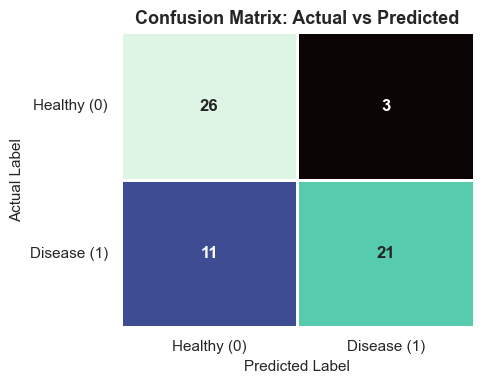

In [125]:
# Visualize Confusion Matrix as a heatmap for clear interpretation
# Rows represent Actual classes and Columns represent Predicted classes
# Helps quickly identify model strengths and types of errors (FP, FN)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12, "weight":"bold"}
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0.5,1.5], ["Healthy (0)", "Disease (1)"])
plt.yticks([0.5,1.5], ["Healthy (0)", "Disease (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [128]:
# Built-in sklearn metrics (validation check)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

accuracy_dt, precision_dt, recall_dt, f1_dt

(0.7704918032786885, 0.875, 0.65625, 0.75)

In [129]:
# Generate detailed classification evaluation report
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.70      0.90      0.79        29
           1       0.88      0.66      0.75        32

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



In [130]:
# Checking Model Score
# Model Score same as accuracy Score
dt_score = model_dt.score(X_test,y_test)
dt_score

0.7704918032786885

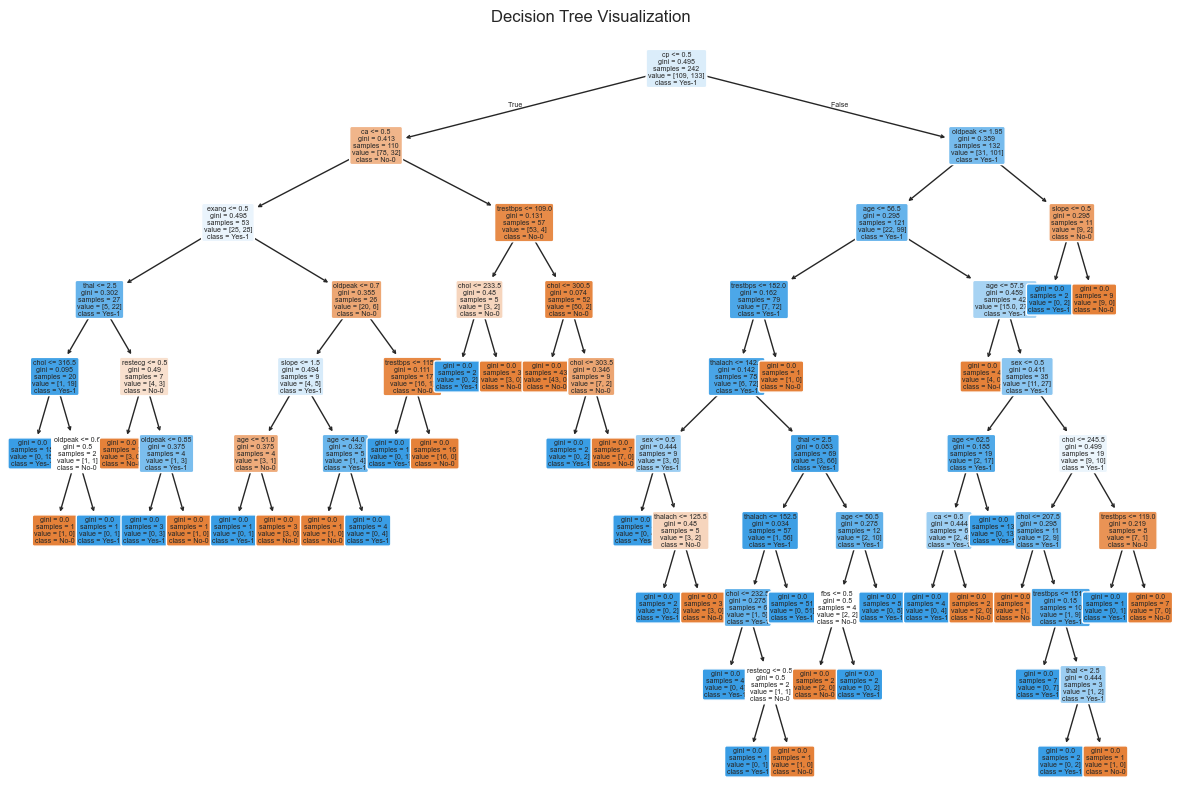

In [131]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 10)) # Adjust figure size for better readability
plot_tree(model_dt,
          feature_names=X.columns,
          class_names=['No-0','Yes-1'],
          filled=True, # Color nodes based on class
          rounded=True, # Round node corners
          fontsize=5) # Adjust font size

plt.title("Decision Tree Visualization")
plt.show() # Display the plot

# Step 5.5: Ensemble ML Model
- `Bagging Technique`: Bags of Multiple ML Model, and each model give it's prediction/classification, final outcome based on majority
- `Boosting Technique`: Next model learn from previous model and boost it minimize error to improve score

### Ensemble Learning: Random Forest Classifier

In [132]:
# Random Forest Classifier
# ------------------------
# Random Forest is an ensemble learning algorithm based on the Bagging technique.
# It builds multiple Decision Trees on different random subsets of data and features.
# Final prediction is obtained by majority voting (classification).

# Key Advantages:
# • Reduces overfitting compared to single Decision Tree
# • Improves generalization performance
# • Handles non-linear patterns effectively

# Default Parameters:
# n_estimators = 100  → number of trees in the forest

In [133]:
# Random Forest Output Logic
# For Regression → final prediction = average of all tree outputs
# For Classification → final prediction = majority vote of all trees
# This ensemble strategy reduces variance and improves model stability.

In [134]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators = 200) # Parameter change Default Tree 100 to 200
model_rf.fit(X_train,y_train) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [135]:
y_pred_rf = model_rf.predict(X_test)

In [136]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[24  5]
 [ 4 28]]


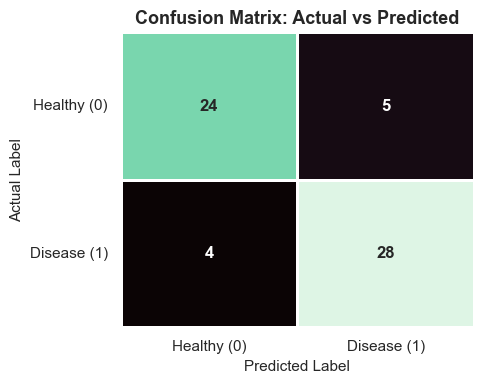

In [137]:
# Visualize Confusion Matrix as a heatmap for clear interpretation
# Rows represent Actual classes and Columns represent Predicted classes
# Helps quickly identify model strengths and types of errors (FP, FN)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12, "weight":"bold"}
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0.5,1.5], ["Healthy (0)", "Disease (1)"])
plt.yticks([0.5,1.5], ["Healthy (0)", "Disease (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [138]:
# Built-in sklearn metrics (validation check)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

accuracy_rf, precision_rf, recall_rf, f1_rf

(0.8524590163934426, 0.8484848484848485, 0.875, 0.8615384615384616)

In [139]:
# Generate detailed classification evaluation report
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [140]:
# Checking Model Score
# Model Score same as accuracy Score
rf_score = model_rf.score(X_test,y_test)
rf_score

0.8524590163934426

# Ensemble Boosting Technique : XGboost

In [141]:
# XGBoost (Extreme Gradient Boosting)
# Boosting-based ensemble algorithm where trees are built sequentially.
# Each new tree learns from errors of previous trees, improving accuracy.
# Known for high performance, regularization, and speed optimization.

In [142]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 1.9 MB/s eta 0:00:54
    --------------------------------------- 1.3/101.7 MB 1.9 MB/s eta 0:00:52
    --------------------------------------- 1.6/101.7 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 2.4/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 2.9/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 3.4/101.7 MB 2.5 MB/s eta 0:00:39
   - -------------------------------------- 3.9/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 4.2/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 4.5/101.7 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 4.5/101.7 MB 2.2 MB/s eta 0:00:45
   -- -


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [144]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier() 
model_xgb.fit(X_train,y_train)  

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [145]:
y_pred_xgb = model_xgb.predict(X_test)

In [146]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[25  4]
 [ 7 25]]


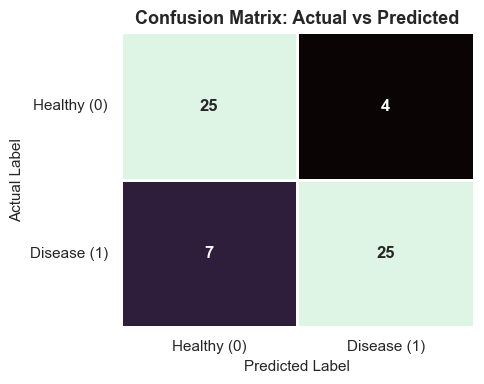

In [147]:
# Visualize Confusion Matrix as a heatmap for clear interpretation
# Rows represent Actual classes and Columns represent Predicted classes
# Helps quickly identify model strengths and types of errors (FP, FN)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12, "weight":"bold"}
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0.5,1.5], ["Healthy (0)", "Disease (1)"])
plt.yticks([0.5,1.5], ["Healthy (0)", "Disease (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [148]:
# Built-in sklearn metrics (validation check)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

accuracy_xgb, precision_xgb, recall_xgb, f1_xgb

(0.819672131147541, 0.8620689655172413, 0.78125, 0.819672131147541)

In [149]:
# Generate detailed classification evaluation report
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        29
           1       0.86      0.78      0.82        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [150]:
# Checking Model Score
# Model Score same as accuracy Score
xgb_score = model_xgb.score(X_test,y_test)
xgb_score

0.819672131147541

# KNN Classification

In [151]:
# KNN — Concept Overview
# K-Nearest Neighbors is a distance-based algorithm.
# It does NOT learn a formula; it stores training data and predicts based on nearest points.

# ---------------------------------------------------
# KNN CLASSIFICATION
# ---------------------------------------------------
# Used when target variable is categorical (ex: 0/1 disease prediction)
# Prediction = Majority vote of nearest neighbors

In [152]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=14) # k= 14
model_knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [155]:
y_pred_knn = model_knn.predict(X_test)

In [156]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[22  7]
 [ 9 23]]


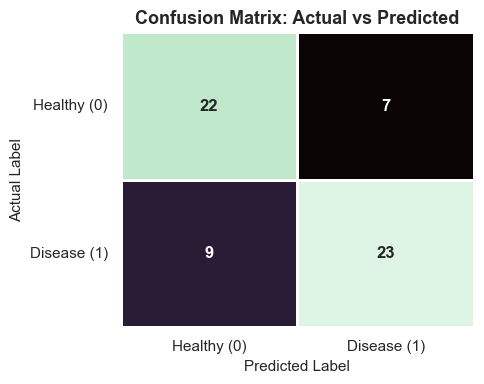

In [157]:
# Visualize Confusion Matrix as a heatmap for clear interpretation
# Rows represent Actual classes and Columns represent Predicted classes
# Helps quickly identify model strengths and types of errors (FP, FN)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=13, fontweight="bold")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12, "weight":"bold"}
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0.5,1.5], ["Healthy (0)", "Disease (1)"])
plt.yticks([0.5,1.5], ["Healthy (0)", "Disease (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [158]:
# Built-in sklearn metrics (validation check)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

accuracy_knn, precision_knn, recall_knn, f1_knn

(0.7377049180327869, 0.7666666666666667, 0.71875, 0.7419354838709677)

In [159]:
# Generate detailed classification evaluation report
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.71      0.76      0.73        29
           1       0.77      0.72      0.74        32

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



In [160]:
# Checking Model Score
# Model Score same as accuracy Score
knn_score = model_knn.score(X_test,y_test)
knn_score

0.7377049180327869

# Artificial Neural Network using Deep Learning

In [161]:
# Traditional ML models perform well on structured datasets with limited complexity.
# Model must receive same feature count/order as used during training.
# Deep learning models (Dense Neural Networks) can capture complex nonlinear
# relationships and interactions among features, making them powerful for
# high-dimensional and large datasets.

In [162]:
# Keras is a high-level neural network API built on top of TensorFlow backend.
# TensorFlow performs mathematical computations efficiently (CPU/GPU).
# Tensor = multidimensional numerical array used for storing and processing data in deep learning.
#TensorFlow is the computation engine; Keras is the interface; tensors are the data structure

In [163]:
!pip install keras
!pip install tensorflow

  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 3.1 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------- ----------------------------- 0.8/2.9 MB 5.1 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.9 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 5.0 MB/s eta 0:00:00
Using cached namex-0.1.0-py3-none-any.whl (5.9 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.5-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 1.8 MB/s eta 0:03:08
   ---------------------------------------- 0.8/332.0 MB 1.4 MB/s eta 0:03:51
   ---------------------------------------- 1.6/332.0 MB 2.0 MB/s eta 0:02:47
   ---------------------------------------- 2.1/332.0 MB 2.2 MB/s eta 0:02:28
   ---------------------------------------- 2.9/332.0 MB 2.5 MB/s eta 0:02:10
   ----------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [164]:
from keras.models import Sequential
from keras.layers import Dense

In [165]:
ann_model = Sequential()

# Hidden layer
ann_model.add(Dense(11, activation='relu', input_dim=13))

# Output layer (binary classification)
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(
    loss='binary_crossentropy',   # Correct loss for binary classification
    optimizer='adam',             # Adaptive optimizer
    metrics=['accuracy']
)

print("Model Built Successfully")

Model Built Successfully


In [167]:
# ================================
# ANN Training (Improved)
# ================================

from tensorflow.keras.callbacks import EarlyStopping

# Stops training when model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,   # Prevent overfitting
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

print("Training Completed")

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7565 - loss: 0.4726 - val_accuracy: 0.7347 - val_loss: 0.5182
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7461 - loss: 0.4813 - val_accuracy: 0.7347 - val_loss: 0.5175
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7306 - loss: 0.4814 - val_accuracy: 0.7143 - val_loss: 0.5240
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7461 - loss: 0.4902 - val_accuracy: 0.7143 - val_loss: 0.5229
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7876 - loss: 0.4775 - val_accuracy: 0.7347 - val_loss: 0.5196
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7668 - loss: 0.4719 - val_accuracy: 0.6939 - val_loss: 0.5271
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7668 - loss: 0.4733 - val_accuracy: 0.7347 - val_loss: 0.5141
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7668 - loss: 0.4705 - val_accuracy: 0.

In [169]:
# ================================
# Prediction & Evaluation
# ================================

# Predict probability
y_pred_prob = ann_model.predict(X_test)

# Convert probability → class label
y_pred_ann = (y_pred_prob > 0.5).astype(int)

# Accuracy
ann_score = accuracy_score(y_test, y_pred_ann)
print("ANN Accuracy:", ann_score)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step 
ANN Accuracy: 0.819672131147541


# All Model Comparison

In [171]:
# ================================
# Collect Model Scores
# ================================

results = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "KNN",
        "ANN"
    ],
    
    "Accuracy": [
        lr_score,
        nb_score,
        svm_score,
        dt_score,
        rf_score,
        xgb_score,
        knn_score,
        ann_score
    ]
}

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort by best model
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy
0,Logistic Regression,0.885246
1,Naive Bayes,0.868852
2,Random Forest,0.852459
3,XGBoost,0.819672
4,ANN,0.819672
5,Decision Tree,0.770492
6,KNN,0.737705
7,SVM,0.704918


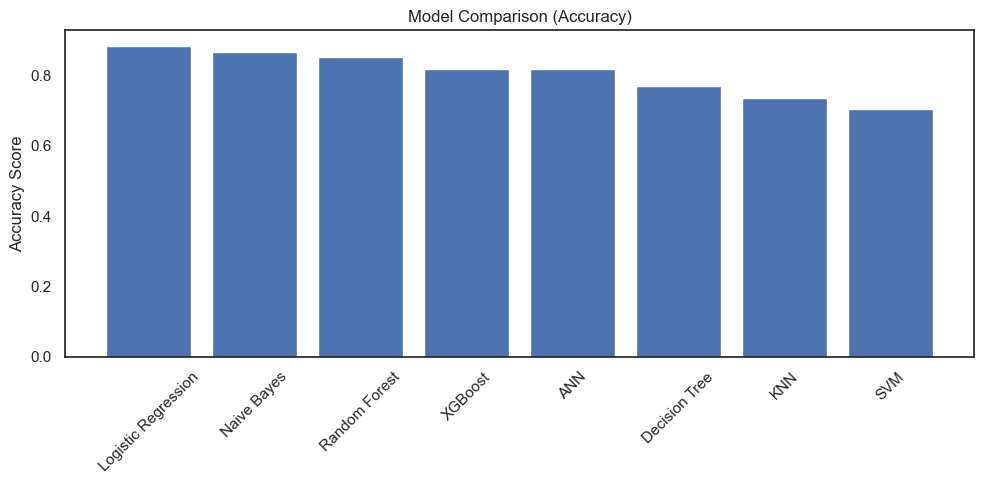

In [172]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy Score")
plt.tight_layout()
plt.show()

In [173]:
best_model = results_df.iloc[0]
print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])

Best Model: Logistic Regression
Accuracy: 0.8852459016393442


##### Among all evaluated models, the one with the highest accuracy score is "Logistic Regression" and it is selected as the final model because it demonstrates the best predictive performance on unseen test data.

# Best Model Save

In [174]:
best_model = model_lr

In [175]:
import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model saved successfully!")

Model saved successfully!
